In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
# Import feral from THIS source repo, not the stale 0.4.0 installed in the pixi env.
# Must run before any `import feral`. If feral was already imported, RESTART THE KERNEL
# and run this cell first (Kernel -> Restart, then run top to bottom).
import torch

import sys
sys.path.insert(0, "/home/dengd3@hhmi.org/feral")

import feral.dataset
assert hasattr(feral.dataset, "ContrastiveVideoDataset"), \
    f"Wrong feral loaded: {feral.dataset.__file__} -- restart the kernel and run this cell first"
print("feral.dataset ->", feral.dataset.__file__)

feral.dataset -> /home/dengd3@hhmi.org/feral/feral/dataset.py


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

len(ds) = 32
{'vid1': torch.Size([64, 3, 224, 224]), 'vid2': torch.Size([64, 3, 224, 224]), 'vid3': torch.Size([64, 3, 224, 224])}


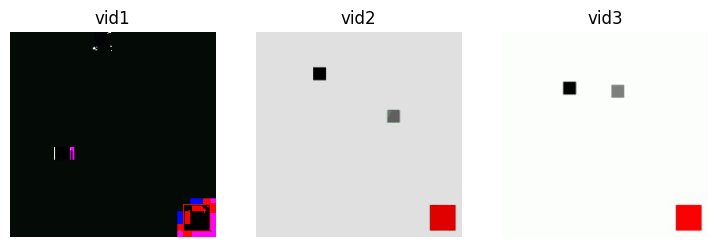

In [12]:
# Making the Dataset

from feral.dataset import ContrastiveVideoDataset
import matplotlib.pyplot as plt

prefix = "/home/dengd3@hhmi.org/feral_project/FERAL_demo_square_mice/videos"                 # dir holding the videos
video_paths = ["synthetic_04.mp4", "synthetic_05.mp4"]            # filenames relative to prefix

ds = ContrastiveVideoDataset(
    video_paths=video_paths,
    prefix=prefix,
    num_samples=32,
    chunk_length=64, chunk_step=1,
    resize_to=224, resize_style="square",
    do_aa=True, seed=0,
)

print("len(ds) =", len(ds))

item = ds[0]
print({k: v.shape for k, v in item.items()})   # each (64, 3, 224, 224)

# undo the vjepa Normalize so frames display with natural colors
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show(frame):
    return (frame * std + mean).permute(1, 2, 0).clamp(0, 1)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for a, k in zip(ax, ("vid1", "vid2", "vid3")):
    a.imshow(show(item[k][0]))          # first frame of each clip
    a.set_title(k); a.axis("off")
plt.show()
# vid1 & vid2: same clip with offset, different augmentation. vid3: a different clip.

In [5]:
# ---- verify FeralModel.forward_features returns feature vectors, not labels ----
import torch
from feral.modeling import build_model
from feral.cli import _load_default_config

cfg = _load_default_config()
cfg['model']['pretrained'] = False        # skip the weight download for a shape check
cfg['training']['compile'] = False        # avoid torch.compile friction while prototyping

model, _ = build_model(cfg, num_classes=2, device=device, with_ema=False)
model.eval()

T = cfg['data']['chunk_length']           # 64
R = cfg['data']['resize_to']              # 256
x = torch.randn(2, T, 3, R, R, device=device)

with torch.no_grad():
    feats  = model.forward_features(x)    # NEW: per-frame feature vectors
    logits = model(x)                     # unchanged: class logits still work
    hello = model.forward(x)

D = model.backbone.hidden_dim
print("feats :", tuple(feats.shape),  "expected", (2, cfg['predict_per_item'], D))
print("logits:", tuple(logits.shape), "expected", (2 * cfg['predict_per_item'], 2))
assert feats.shape == (2, cfg['predict_per_item'], D)
print("OK — model returns (B, 64, D) features")

# For a *semantic* check (vid1~vid2 closer than vid1~vid3), set pretrained=True
# above, build a ContrastiveVideoDataset at resize_to=R, batch a triplet through
# forward_features, mean-pool over frames, and compare cosine similarities.

/home/dengd3@hhmi.org/feral_project/.pixi/envs/default/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


feats : (2, 64, 1024) expected (2, 64, 1024)
logits: (128, 2) expected (128, 2)
OK — model returns (B, 64, D) features


In [7]:
# ---- run contrastive pretraining in the notebook (mirrors train.py phase 1) ----
from torch.utils.data import DataLoader
from feral.dataset import ContrastiveVideoDataset, collate_fn_contrastive
from feral.modeling import build_model, build_contrastive_objects
from feral.loops import train_contrastive_epoch
from feral.utils import save_model
from feral.cli import _load_default_config

cfg = _load_default_config()
cfg['model']['pretrained'] = True                 # start from the VJEPA backbone
cfg['training']['compile'] = False
cfg['training']['contrastive_epochs'] = 3         # bump up for a real run
cfg['training']['contrastive_num_samples'] = 128  # triplets drawn per epoch
cfg['training']['train_bs'] = 2                   # 3 clips/item -> keep small (VRAM)
R = cfg['data']['resize_to']                      # 256, matches the backbone

ds = ContrastiveVideoDataset(
    video_paths=video_paths, prefix=prefix,
    num_samples=cfg['training']['contrastive_num_samples'],
    chunk_length=cfg['data']['chunk_length'], chunk_step=cfg['data']['chunk_step'],
    resize_to=R, resize_style=cfg['data']['resize_style'], do_aa=True, seed=0,
)
loader = DataLoader(ds, batch_size=cfg['training']['train_bs'], shuffle=True,
                    drop_last=True, collate_fn=collate_fn_contrastive)

model, _ = build_model(cfg, num_classes=2, device=device, with_ema=False)
opt, sched = build_contrastive_objects(cfg, model, loader)   # AdamW + cosine schedule

for epoch in range(cfg['training']['contrastive_epochs']):
    ds.resample()                                  # fresh triplets each epoch
    avg = train_contrastive_epoch(               # per-epoch tqdm bar; log_fn=None (no wandb)
        model, loader, opt, sched, device=device,
        margin=cfg['training']['contrastive_margin'],
    )
    print(f"epoch {epoch}: contrastive loss {avg:.4f}")

# save so the extract-embeddings / finetune paths can reuse the trained encoder
save_model(model, "/tmp/nb_pretrained.pt",
           {'class_names': {0: 'a', 1: 'b'}, 'is_multilabel': False, 'cfg': cfg})
print("saved -> /tmp/nb_pretrained.pt")

# `model` + `cfg` now hold the CONTRASTIVELY-TRAINED encoder. Re-run the extract
# cell + viz cell below to compare its embeddings vs the pretrained baseline.
# Compute: 3 ViT-L forwards/step; 128 samples / bs2 = 64 steps x 3 epochs ~ 200
# steps (a few min). Scale num_samples/epochs up for a serious run; drop train_bs
# to 1 or set cfg['model']['gradient_checkpointing']=True if you hit OOM.

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 587/587 [00:00<00:00, 12251.29it/s]
VJEPA2Model LOAD REPORT from: facebook/vjepa2-vitl-fpc32-256-diving48
Key                                                              | Status     |  | 
-----------------------------------------------------------------+------------+--+-
pooler.self_attention_layers.{0, 1, 2}.self_attn.v_proj.bias     | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.layer_norm2.weight        | UNEXPECTED |  | 
pooler.cross_attention_layer.mlp.fc1.weight                      | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.mlp.fc1.weight            | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.q_proj.bias     | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.k_proj.bi

epoch 0: contrastive loss 0.6021


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [01:09<00:00,  1.08s/it]


epoch 1: contrastive loss 0.2096


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [01:09<00:00,  1.09s/it]


epoch 2: contrastive loss 0.2194
saved -> /tmp/nb_pretrained.pt


In [9]:
# ---- extract one embedding per chunk over the whole video folder ----
from feral.embeddings import extract_embeddings_folder

# reuses `model` + `cfg` from the cells above (pretrained encoder, resize_to=256)
emb, ids = extract_embeddings_folder(
    model, cfg, prefix, batch_size=4, num_workers=2,
    save_path="/tmp/feral_emb.npz",
)
print("emb:", tuple(emb.shape), "| D:", model.backbone.hidden_dim, "| n_chunks:", len(ids))
print("first ids (file, start_frame):", ids[:3])

17:44:34 feral.inference_folder INFO: Found 18 video files out of 18 files in /home/dengd3@hhmi.org/feral_project/FERAL_demo_square_mice/videos
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 143/143 [00:48<00:00,  2.97it/s]

emb: (571, 1024) | D: 1024 | n_chunks: 571
first ids (file, start_frame): [('synthetic_00.mp4', 0), ('synthetic_00.mp4', 32), ('synthetic_00.mp4', 64)]


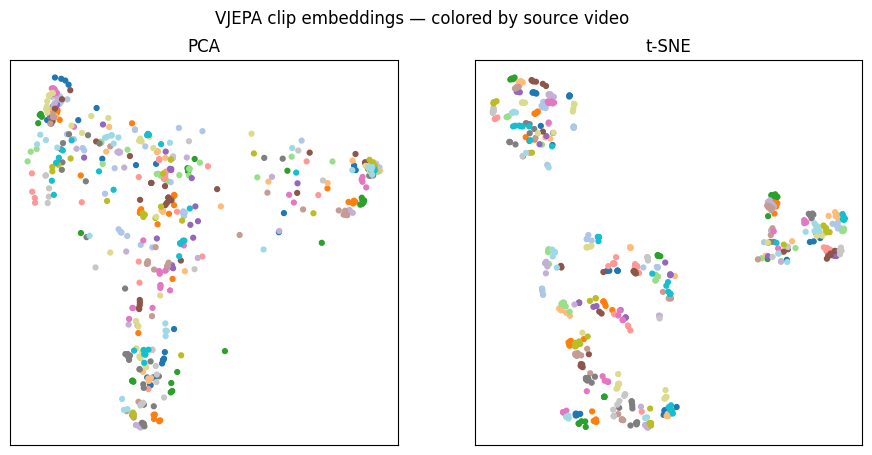

In [10]:
# ---- 2-D projections of the embeddings (PCA + t-SNE), colored by source video ----
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X = emb.numpy()
files = np.array([f for f, _ in ids])
codes = {f: i for i, f in enumerate(sorted(set(files)))}
c = [codes[f] for f in files]

pca = PCA(n_components=2).fit_transform(X)
tsne = TSNE(n_components=2, perplexity=min(30, max(2, len(X) // 3)),
            init="pca").fit_transform(X)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for a, proj, name in ((ax[0], pca, "PCA"), (ax[1], tsne, "t-SNE")):
    a.scatter(proj[:, 0], proj[:, 1], c=c, cmap="tab20", s=12)
    a.set_title(name); a.set_xticks([]); a.set_yticks([])
fig.suptitle("VJEPA clip embeddings — colored by source video")
plt.show()
# Each point = one 64-frame chunk. Look for structure (clips clustering by
# video / content). This is the baseline before any contrastive training.

/home/dengd3@hhmi.org/feral_project/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dengd3@hhmi.org/feral_project/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


6 behavior clusters | 3.2% noise


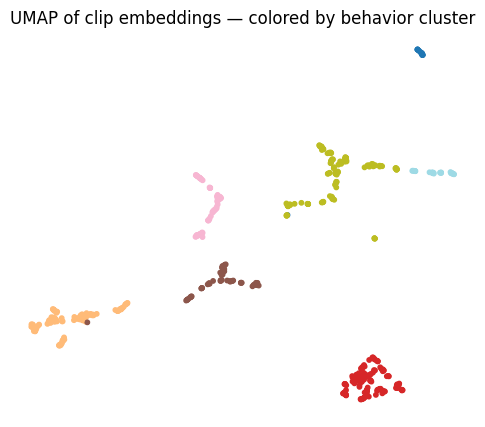

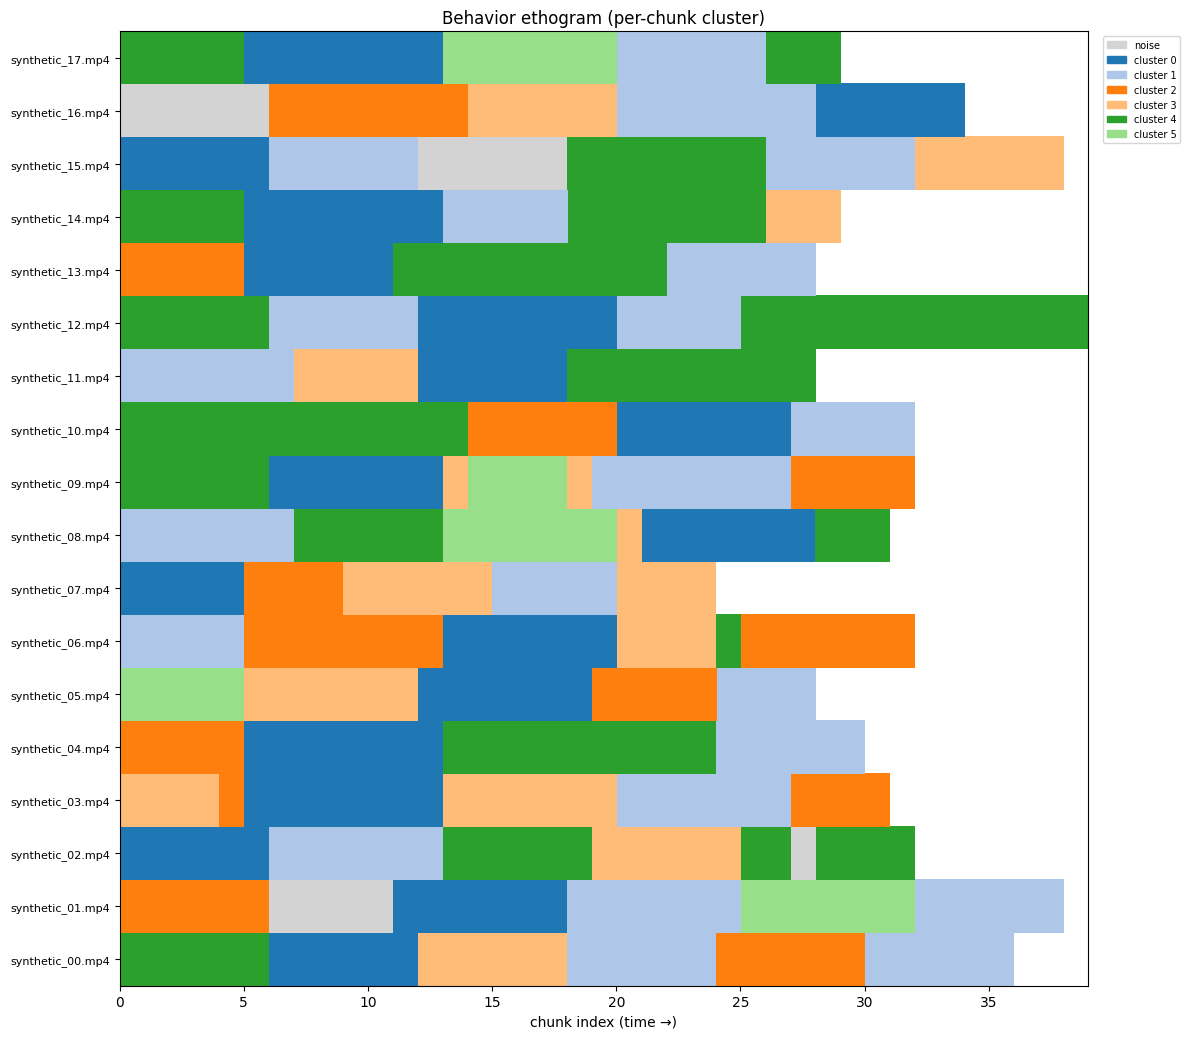

In [11]:
# ---- unsupervised behavior discovery: UMAP -> HDBSCAN -> ethogram ----
# reuses `emb` + `ids` from the extract cell above
from feral.behavior import cluster_embeddings, behavior_ethogram

labels, emb2d = cluster_embeddings(emb, min_cluster_size=25)
n_clusters = len(set(labels.tolist())) - (1 if -1 in labels else 0)
print(f"{n_clusters} behavior clusters | {(labels == -1).mean():.1%} noise")

# UMAP colored by discovered behavior cluster
plt.figure(figsize=(6, 5))
plt.scatter(emb2d[:, 0], emb2d[:, 1], c=labels, cmap="tab20", s=10)
plt.title("UMAP of clip embeddings — colored by behavior cluster")
plt.axis("off"); plt.show()

# per-video ethogram (one row per video, chunks in time, colored by cluster)
behavior_ethogram(ids, labels)
plt.show()

# To compare PRETRAINED vs CONTRASTIVELY-TRAINED: run the extract cell with each
# `model` (baseline backbone vs the trained one from the pretraining cell), then
# re-run this cell and eyeball whether the trained encoder gives cleaner, more
# temporally-contiguous ethogram bands and better-separated UMAP clusters.

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from collections import defaultdict
from pathlib import Path

with open("/home/dengd3@hhmi.org/feral_project/FERAL_demo_square_mice/labels_singlelabel.json") as f:
    labels_single_json = json.load(f)

SINGLE_CLASS_NAMES = {int(k): v for k, v in labels_single_json["class_names"].items()}
# {0: 'other', 1: 'copulation', 2: 'eating', 3: 'sleeping', 4: 'playing'}
print(SINGLE_CLASS_NAMES)

with open("/home/dengd3@hhmi.org/feral_project/FERAL_demo_square_mice/labels_multilabel.json") as f:
    labels_multi_json = json.load(f)

MULTI_CLASS_NAMES = {int(k): v for k, v in labels_multi_json["class_names"].items()}
print(MULTI_CLASS_NAMES)

{0: 'other', 1: 'copulation', 2: 'eating', 3: 'sleeping', 4: 'playing'}
{0: 'mouse_a_eating', 1: 'mouse_a_sleeping', 2: 'mouse_b_eating', 3: 'mouse_b_sleeping', 4: 'copulation', 5: 'playing'}
